![Alt Text](https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/header.png)

<a href="https://colab.research.google.com/github/msfasha/307304-Data-Mining/blob/main/Part%203-Classification/3-1-classification_logistic_regression_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Classification

Classification is a type of supervised learning where the goal is to predict a categorical label (like "yes" or "no") instead of a continuous value. For example, predicting if an email is spam or not, or if a customer will make a purchase.



## Binary Classification Examples

| **Problem**            | **Example Features**                              | **Binary Outcome**               |
|-------------------------|--------------------------------------------------|-----------------------------------|
| **Churn Prediction**    | Customer tenure, monthly charges, contract type, number of support calls, payment method | Churn (1) / Retain (0)           |
| **Spam Detection**      | Email subject length, presence of "urgent", sender reputation, email contains link, word frequency of common spam terms | Spam (1) / Not Spam (0)          |
| **Loan Approval**       | Applicant income, credit score, loan amount, employment status, debt-to-income ratio | Approved (1) / Denied (0)        |
| **Fraud Detection**     | Transaction amount, location mismatch, card usage frequency, time of transaction, device used | Fraudulent (1) / Legitimate (0)  |
| **Disease Diagnosis**   | Age, symptoms present (e.g., fever, cough), test result values, exposure history | Disease Present (1) / Absent (0) |
| **Customer Satisfaction** | Product rating, delivery time, customer service response time, product return | Satisfied (1) / Unsatisfied (0)  |
| **Ad Click Prediction** | Ad type, user device, time of day, user demographics, previous interaction with ads | Clicked (1) / Not Clicked (0)    |
| **Credit Card Default** | Payment history, total balance, age of account, income level, missed payments count | Default (1) / No Default (0)     |
| **Employee Attrition**  | Age, years at company, job satisfaction score, promotion in last 2 years, average working hours | Left (1) / Stayed (0)            |
| **Sentiment Analysis**  | Text length, presence of positive/negative words, punctuation usage, time posted | Positive (1) / Negative (0)      |

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/sample_churn_dataset.png" alt="Sampel Churn Dataset" width="1200"/>
</div>

## Logistic Regression: The First Step in Classification

**Why Not Use Linear Regression for Classification?**  
Linear regression is great for predicting continuous numbers (like prices) but struggles with binary outcomes (e.g., yes/no, spam/not spam). Logistic regression is designed specifically for binary classification.

**What is Logistic Regression?**  
Logistic regression predicts the probability that an instance belongs to a certain class. The core of logistic regression is the **sigmoid function**, which takes any input value and squeezes it between 0 and 1. This makes it perfect for probability predictions.

**The Sigmoid Function:**  
Here’s the formula for the sigmoid function:
$
\sigma(x) = \frac{1}{1 + e^{-x}}
$
This function converts any input into a value between 0 and 1. In logistic regression:
- If the probability (output) is above 0.5, the model predicts “yes” (or class 1).
- If it’s below 0.5, it predicts “no” (or class 0).

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/sigmoid.png" alt="Logistic Regression and the Sigmoid Function" width="600"/>
</div>

## Practical Example using Python

We will use a using [Diabetes Dataset](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) dataset to demonstrate classification using scikit Learn Library.<br>

**Dataset Card: Loan Default Prediction Dataset**

**Context**<br>
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes.

**Content**<br>
Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

- Pregnancies: Number of times pregnant
- Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- BloodPressure: Diastolic blood pressure (mm Hg)
- SkinThickness: Triceps skin fold thickness (mm)
- Insulin: 2-Hour serum insulin (mu U/ml)
- BMI: Body mass index (weight in kg/(height in m)^2)
- DiabetesPedigreeFunction: Diabetes pedigree function
- Age: Age (years)
- Outcome: Class variable (0 or 1)

### Solution Steps
1. Load the Data.
2. Split the data intro training and testing datasets.
3. Define the classification model.
4. Fit the model.
5. Make predictions and test performance.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the dataset from the URL
url = "https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/datasets/diabetes.csv"
data = pd.read_csv(url)

# Define features (X) and target (y)
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction','Age']]
y = data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train logistic regression model
model = LogisticRegression(max_iter=200)  # Increase iterations to 200
model.fit(X_train, y_train)

# Predict on test data
predictions = model.predict(X_test)
print("Predictions:", predictions)

Predictions: [0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 1
 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 1]


### **Evaluating Classification Performance**

### 1. **Confusion Matrix**
- **Definition**: A table summarizing the counts of true positives, false positives, true negatives, and false negatives.
- **Structure**:

|                  | Predicted Diabetic | Predicted Non-Diabetic |
|------------------|--------------------|-------------------------|
| Actual Diabetic  | True Positive (TP) | False Negative (FN)    |
| Actual Non-Diabetic | False Positive (FP) | True Negative (TN)    |

- **Purpose**: Provides a detailed breakdown of predictions, enabling the calculation of key metrics and insights into where the model errs.

### Example: Diabetes Prediction
- **True Positive (TP)**: Correctly predicts a diabetic patient.
- **False Positive (FP)**: Misdiagnoses a non-diabetic patient as diabetic.
- **True Negative (TN)**: Correctly predicts a non-diabetic patient.
- **False Negative (FN)**: Misses a diabetic patient.

***Manullay Compute the Accuracy Measures***

In [29]:
probabilities = model.predict_proba(X_test)[:,1]
resultdf = pd.DataFrame({'Actual': y_test, 'Probability = 1': probabilities, 'Predicted': predictions})

# Add a column 'Result' to classify each row as TP, TN, FP, FN
resultdf['Result'] = resultdf.apply(
    lambda row: 'TP' if row['Actual'] == 1 and row['Predicted'] == 1 else
                'TN' if row['Actual'] == 0 and row['Predicted'] == 0 else
                'FP' if row['Actual'] == 0 and row['Predicted'] == 1 else
                'FN',
    axis=1
)
print(resultdf.head(20))
print("----------------------------------------------")
# sum the values
count_df = resultdf.groupby('Result').size().reset_index(name='Count')
print(count_df)

# 1. .size():
# Purpose: It counts the number of rows in each group.
# Result: Returns a Series where the index corresponds to the group (e.g., Result column values like TP, TN, etc.), and the value is the count of rows in that group.
# Without .size(): You can't directly count rows in a groupby() operation because methods like .sum() and .mean() aggregate numerical columns, not counts. If you're looking for row counts, .size() is necessary.

# 2. .reset_index():
# Purpose: Converts the group labels (from the groupby() index) back into regular columns of a new DataFrame.
# Result: Gives you a DataFrame where the group labels (e.g., TP, TN, etc.) appear as regular data in a column.

     Actual  Probability = 1  Predicted Result
444       1         0.232247          0     FN
27        0         0.048196          0     TN
319       1         0.730660          1     TP
639       0         0.030942          0     TN
338       1         0.728735          1     TP
352       0         0.069097          0     TN
469       0         0.834939          1     FP
731       1         0.223891          0     FN
334       0         0.044655          0     TN
350       0         0.289963          0     TN
761       1         0.925461          1     TP
101       0         0.257544          0     TN
694       0         0.045408          0     TN
414       1         0.342852          0     FN
596       0         0.193507          0     TN
223       0         0.611813          1     FP
747       0         0.358513          0     TN
601       0         0.143841          0     TN
655       1         0.587713          1     TP
486       0         0.491914          0     TN
-------------

**Use the confusion_matrix function from sklearn to get the accuracy measures**

In [ ]:
from sklearn.metrics import confusion_matrix

# Enhanced display of the confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

# The ravel() function in this context is used to "flatten" the confusion matrix array, making it a 1-dimensional array instead of a 2x2 matrix.
# When you call cm.ravel() on a 2x2 confusion matrix, it returns the values in the order [TN, FP, FN, TP]. This allows you to directly assign these values to the variables tn, fp, fn, and tp,
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

Confusion Matrix:
 [[80 14]
 [23 37]]
True Negatives (TN): 80
False Positives (FP): 14
False Negatives (FN): 23
True Positives (TP): 37


**Display an Enhanced Confusion Matrix**

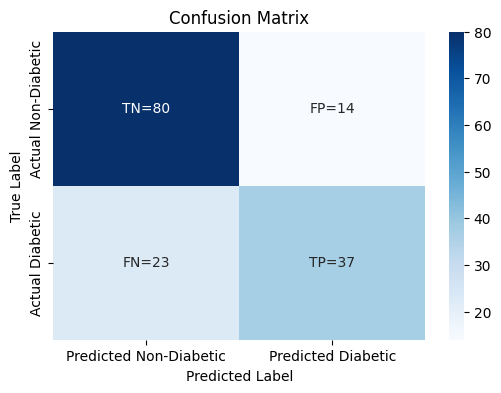

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the confusion matrix with updated labels
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=[[f"TN={tn}", f"FP={fp}"], [f"FN={fn}", f"TP={tp}"]],
    fmt="",
    cmap='Blues',
    xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
    yticklabels=['Actual Non-Diabetic', 'Actual Diabetic']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 2. **Accuracy**
Accuracy is the most basic metric for evaluating classification models, measuring the proportion of correct predictions.<br>
- **Definition**: The ratio of correct predictions to total predictions.
- **Formula**:

  $
  \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}
  $

- **Limitation**: Accuracy can be misleading with imbalanced data. For example, if only 10% of patients have diabetes, predicting all as "non-diabetic" yields 90% accuracy but fails to identify any diabetic cases.

### 3. **Precision**
- **Definition**: The proportion of correctly predicted positives (diabetic) out of all predicted positives.
- **Formula**:

  $
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
  $

- **When Useful**: Precision matters when false positives (e.g., diagnosing non-diabetic patients as diabetic) need to be minimized, reducing unnecessary interventions or stress.

### 4. **Recall** (Sensitivity or True Positive Rate)
- **Definition**: The proportion of correctly identified positives out of all actual positives.
- **Formula**:

  $
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
  $

- **When Useful**: Recall is critical when missing positive cases (e.g., undiagnosed diabetic patients) is costly, ensuring timely intervention for high-risk individuals.

### 5. **Why Both Metrics Matter**
- **High Precision**: Ensures fewer non-diabetic patients are misdiagnosed as diabetic.
- **High Recall**: Ensures most diabetic patients are identified.
- The trade-off depends on the specific goal: reducing unnecessary diagnoses (precision) or minimizing missed diagnoses (recall).

### 5. **F1 Score**
- **Definition**: The harmonic mean of precision and recall, balancing the two metrics.<br>
- Higher F1 Scores are better, as they indicate a good balance between precision (low false positives) and recall (low false negatives).<br>
- A perfect score of 1 is ideal but rare in real-world applications.<br>

- **Threshold for "good" F1 scores depends on the context:**<br>
  -  In many cases, an F1 score above 0.7 is considered good.
  -  In highly challenging tasks or imbalanced datasets, even 0.5–0.6 might be acceptable.
- **Formula**:

  $
  \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $

- **When Useful**: Ideal for imbalanced datasets when both false positives and false negatives are costly.

### Choosing Metrics
- **High Precision**: Prioritize to reduce unnecessary treatments.
- **High Recall**: Prioritize to minimize undiagnosed diabetes.
- **F1 Score**: Best for balancing precision and recall, especially in imbalanced datasets.

By carefully analyzing these metrics, we can optimize the model's performance to meet healthcare goals, ensuring both effective and efficient predictions for diabetes diagnosis.

**Example: Calculating Metrics in Python**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example evaluation
accuracy = round(accuracy_score(y_test, predictions),2)
precision = round(precision_score(y_test, predictions),2)
recall = round(recall_score(y_test, predictions),2)
f1 = round(f1_score(y_test, predictions),2)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.76
Precision: 0.73
Recall: 0.62
F1-Score: 0.67


### ROC Curve and AUC (Area Under the Curve)

After evaluating a classification model with accuracy, precision, recall, F1 score, and the confusion matrix, another valuable tool is the **ROC Curve** and the **AUC-ROC score**.

**What is the ROC Curve?**

The **Receiver Operating Characteristic (ROC) Curve** shows the performance of a classification model by plotting two metrics:
- **True Positive Rate (TPR)** (or **Recall**): The proportion of actual positive cases that the model correctly identifies.
- **False Positive Rate (FPR)**: The proportion of actual negative cases that the model incorrectly identifies as positive.

On the ROC curve:
- **X-axis** represents the **False Positive Rate** (FPR).
- **Y-axis** represents the **True Positive Rate** (TPR).

The ROC curve shows the trade-off between TPR and FPR across different threshold levels, allowing us to see how well the model distinguishes between the two classes (e.g., defaulters and non-defaulters) at various thresholds.

**What is AUC (Area Under the Curve)?**

The **AUC-ROC score** summarizes the ROC curve by calculating the total area under it:
- An AUC of **1.0** represents a perfect model that separates the two classes perfectly.
- An AUC of **0.5** indicates a model with no predictive power, equivalent to random guessing.
- Higher AUC values indicate a stronger model with better class separation.

### Applying the ROC Curve and AUC in Our Code

Since our model uses logistic regression, we can calculate and plot the ROC curve to assess its performance across different thresholds. The AUC score will provide a single metric summarizing the model's ability to differentiate between defaulters and non-defaulters.

### Example Code to Plot the ROC Curve and Calculate AUC

AUC-ROC Score: 0.8553191489361702


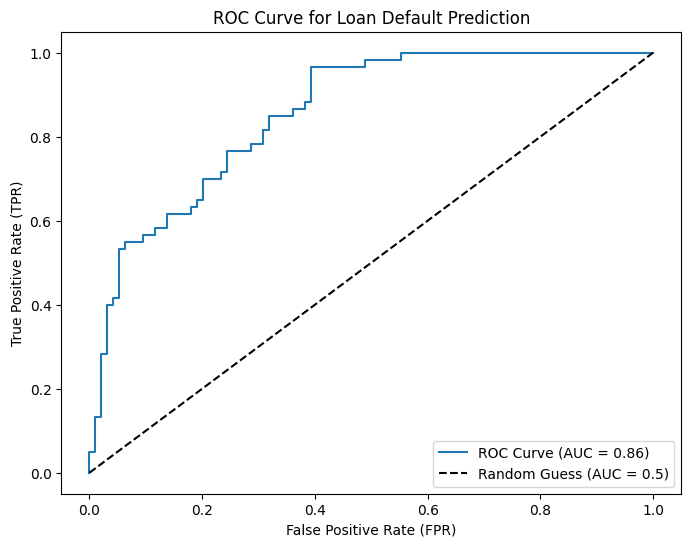

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
probabilities = model.predict_proba(X_test)[:, 1]  # Extract probabilities for class 1 (default)

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

# Calculate the AUC score
auc_score = roc_auc_score(y_test, probabilities)
print("AUC-ROC Score:", auc_score)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Loan Default Prediction")
plt.legend(loc="lower right")
plt.show()

### Interpreting the ROC Curve and AUC Score

In this plot:
- The **ROC Curve** helps us see how well the model performs at distinguishing defaulters from non-defaulters across different thresholds.
- The **AUC score** gives a single-value summary of the model’s ability to distinguish between classes. A higher AUC indicates better performance.

For instance:
- An **AUC close to 1** indicates that the model is effective at identifying defaulters and non-defaulters.
- If the **AUC is around 0.5**, the model performs no better than random guessing.

By using the ROC curve and AUC score, we gain a deeper understanding of how the model performs at varying thresholds, beyond just accuracy. This is especially valuable in loan default prediction, where thresholds for flagging risky applicants can be adjusted based on the bank’s risk tolerance.